In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import linecache
import warnings
import shutil
import zipfile

warnings.filterwarnings('ignore')

In [2]:
import os
import shutil
import zipfile

if os.path.exists('recordings'):
    shutil.rmtree('recordings')
os.makedirs('recordings')

zip_files = [f for f in os.listdir() if f.endswith('.zip')]


for zip_name in zip_files:
    temp_dir = f'temp_unzip_{zip_name}'
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(temp_dir)

    count = 0
    for root, dirs, files in os.walk(temp_dir):
        for file in files:
            if file.lower().endswith('.csv'):
                src_path = os.path.join(root, file)
                dst_path = os.path.join('recordings', file)

                if os.path.exists(dst_path):
                    base, ext = os.path.splitext(file)
                    dst_path = os.path.join('recordings', f"{base}_{zip_name}{ext}")

                shutil.move(src_path, dst_path)
                count += 1

    shutil.rmtree(temp_dir)
    print(f"{count} CSV files from {zip_name} moved to 'recordings'.")



95 CSV files from recordings.zip moved to 'recordings'.


In [3]:
HEADER_ROW_COUNT = 6

def load_file(file_path):
    try:
        if os.path.getsize(file_path) == 0:
            return None

        line3 = linecache.getline(file_path, 3).strip()
        line4 = linecache.getline(file_path, 4).strip()

        if ',' not in line3 or ',' not in line4:
            print(f"Skipping {os.path.basename(file_path)}: Invalid metadata format.")
            return None

        walking_or_running = line3.split(',')[1].strip()

        raw_step_count = line4.split(',')[1].strip()
        try:
            step_count = int(raw_step_count)
        except ValueError:
            print(f"Skipping {os.path.basename(file_path)}: Step count '{raw_step_count}' is not a number.")
            return None

        data = pd.read_csv(file_path, header=HEADER_ROW_COUNT)

        if data.shape[1] == 7:
            data.columns = ['Time [sec]', 'ACC X', 'ACC Y', 'ACC Z', 'GYRO X', 'GYRO Y', 'GYRO Z']
        else:
            return None

        return data, walking_or_running, step_count

    except Exception as e:
        print(f"Error loading {os.path.basename(file_path)}: {e}")
        return None

In [4]:
def load_all_recordings(dir_path):
    recordings_data = pd.DataFrame(columns=['file_name', 'sensor_data', 'walking_or_running', 'actual_step_count'])
    files = os.listdir(dir_path)
    files = sorted(files)

    for filename in files:
        file_path = os.path.join(dir_path, filename)

        if os.path.isfile(file_path):
            result = load_file(file_path)

            if result is not None:
                data, walking_or_running, step_count = result

                new_row = pd.DataFrame({
                    'file_name': [filename],
                    'sensor_data': [data],
                    'walking_or_running': [walking_or_running],
                    'actual_step_count': [step_count]
                })

                recordings_data = pd.concat([recordings_data, new_row], ignore_index=True)

    return recordings_data

In [5]:
def add_columns(recordings_data):

    def extract_total_recording_time(sensor_data):
        return (sensor_data['Time [sec]'].iloc[-1] - sensor_data['Time [sec]'].iloc[0]) / 60.0

    recordings_data['total_time_in_minutes'] = recordings_data['sensor_data'].map(extract_total_recording_time)
    recordings_data['actual_cadence'] = recordings_data['actual_step_count'] / recordings_data['total_time_in_minutes']

    def calculate_norm(sensor_data):
        required_cols = ['ACC X', 'ACC Y', 'ACC Z']
        return pd.DataFrame(zip(sensor_data['Time [sec]'], np.linalg.norm(sensor_data[required_cols].values, axis=1)), columns=['Time [sec]', 'acc_norm'])

    recordings_data['acc_norm_data'] = recordings_data['sensor_data'].map(calculate_norm)

    return recordings_data

In [6]:
recordings_data = load_all_recordings('/content/recordings')
recordings_data = add_columns(recordings_data)

In [7]:
recordings_data

,file_name,sensor_data,walking_or_running,actual_step_count,total_time_in_minutes,actual_cadence,acc_norm_data
0,Move_log_20260122_102655.csv,Time [sec] ACC X ACC Y ACC Z GYRO X ...,Walking,60,2.119933,28.302777,Time [sec] acc_norm 0 33.618 ...
1,Move_log_20260122_102743.csv,Time [sec] ACC X ACC Y ACC Z GYRO X ...,Walking,60,0.804117,74.616038,Time [sec] acc_norm 0 160.882 ...
2,Move_log_20260122_102835.csv,Time [sec] ACC X ACC Y ACC Z GYRO X ...,Walking,60,0.869817,68.980053,Time [sec] acc_norm 0 209.197 6...
3,Move_log_20260122_103016.csv,Time [sec] ACC X ACC Y ACC Z GYRO X ...,Walking,60,1.676367,35.791692,Time [sec] acc_norm 0 261.454 ...
4,Move_log_20260122_103101.csv,Time [sec] ACC X ACC Y ACC Z GYRO X ...,Walking,60,0.768400,78.084331,Time [sec] acc_norm 0 362.104 ...
...,...,...,...,...,...,...,...
90,recording_0051.csv,Time [sec] ACC X ACC Y ACC Z GYRO ...,Walking,99,0.703433,140.738284,Time [sec] acc_norm 0 11.964 10...
91,recording_0052.csv,Time [sec] ACC X ACC Y ACC Z GYRO ...,Walking,120,0.685133,175.14839,Time [sec] acc_norm 0 19.103 10...
92,recording_0053.csv,Time [sec] ACC X ACC Y ACC Z GYRO X ...,Walking,73,1.242017,58.775379,Time [sec] acc_norm 0 585.931 9...
93,recording_0054.csv,Time [sec] ACC X ACC Y ACC Z GYRO X ...,Walking,85,1.281567,66.325071,Time [sec] acc_norm 0 807.203 9...


In [8]:
# recordings_data.iloc[0,:]['sensor_data']

In [9]:
# recordings_data.iloc[0,:]['acc_norm_data']

In [10]:
print("📊 Raw Activity Distribution (Before QA):")
print(recordings_data['walking_or_running'].value_counts())


📊 Raw Activity Distribution (Before QA):
walking_or_running
Walking     52
Running     37
LiveView     6
Name: count, dtype: int64


In [11]:
import numpy as np

def is_gyro_dead(sensor_df, threshold=1e-6):
    gyro_cols = ['GYRO X', 'GYRO Y', 'GYRO Z']
    gyro_stds = sensor_df[gyro_cols].std()
    return (gyro_stds < threshold).all()

def is_too_short(sensor_df, min_seconds=10):
    duration = sensor_df['Time [sec]'].iloc[-1] - sensor_df['Time [sec]'].iloc[0]
    return duration < min_seconds

def is_mostly_static(sensor_df, static_threshold=0.1, percent_static=0.25):
    acc_cols = ['ACC X', 'ACC Y', 'ACC Z']
    diffs = sensor_df[acc_cols].diff().fillna(0)
    movement_mag = np.linalg.norm(diffs, axis=1)

    static_ratio = np.mean(movement_mag < static_threshold)

    return static_ratio > percent_static

bad_ground_truth_files = [
    'recording_0030.csv',
    'recording_0045.csv',
    'recording_0047.csv',
    'recording_0052.csv'
]

# Calculate Masks for all filters
mask_dead_gyro = recordings_data['sensor_data'].apply(is_gyro_dead)
mask_live_view = recordings_data['walking_or_running'] == 'LiveView'
mask_short = recordings_data['sensor_data'].apply(lambda x: is_too_short(x, min_seconds=10))
mask_static = recordings_data['sensor_data'].apply(lambda x: is_mostly_static(x, percent_static=0.5))
mask_bad_gt = recordings_data['file_name'].isin(bad_ground_truth_files)


count_dead = mask_dead_gyro.sum()
count_live = (mask_live_view & ~mask_dead_gyro).sum()
count_short = (mask_short & ~mask_dead_gyro & ~mask_live_view).sum()
count_static = (mask_static & ~mask_dead_gyro & ~mask_live_view & ~mask_short).sum()
count_bad_gt = (mask_bad_gt & ~mask_dead_gyro & ~mask_live_view & ~mask_short & ~mask_static).sum()
dead_gyro_df = recordings_data[mask_dead_gyro].copy()

# Keep rows that passed ALL checks
final_valid_mask = ~(mask_dead_gyro | mask_live_view | mask_short | mask_static | mask_bad_gt)
recordings_data = recordings_data[final_valid_mask].reset_index(drop=True)

print(f"Dead Gyroscope files removed: {count_dead}")
print(f"LiveView activity files removed: {count_live}")
print(f"Short files removed (<10s): {count_short}")
print(f"Mostly Static files removed (>50%): {count_static}")
print(f"Bad Ground Truth files removed: {count_bad_gt}")
print(f"Valid recordings remaining: {len(recordings_data)}")

if mask_bad_gt.any():
    print(f"Removed specific files: {bad_ground_truth_files}")

Dead Gyroscope files removed: 40
LiveView activity files removed: 6
Short files removed (<10s): 0
Mostly Static files removed (>50%): 0
Bad Ground Truth files removed: 4
Valid recordings remaining: 45
Removed specific files: ['recording_0030.csv', 'recording_0045.csv', 'recording_0047.csv', 'recording_0052.csv']


## Classifier

In [12]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier


# Feature Extraction
def extract_norm_features(norm_df):
    return pd.Series({
        'acc_mean': norm_df['acc_norm'].mean(),
        'acc_std':  norm_df['acc_norm'].std(),
        'acc_max':  norm_df['acc_norm'].max()
    })

# Extract features from the existing column
features_df = recordings_data['acc_norm_data'].apply(extract_norm_features)

X = pd.concat([features_df, recordings_data['actual_cadence']], axis=1)
y = recordings_data['walking_or_running']



In [13]:
# Setup Classifier and 5-Fold Cross-Validation
clf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run Cross-Validation for multiple metrics
scoring = ['accuracy', 'f1_weighted']
results = cross_validate(clf, X, y, cv=cv, scoring=scoring)

print(f"--- 5-Fold Cross-Validation (using existing acc_norm) ---")
print(f"Mean Accuracy: {results['test_accuracy'].mean():.4f} (±{results['test_accuracy'].std():.4f})")
print(f"Mean F1 Score:  {results['test_f1_weighted'].mean():.4f} (±{results['test_f1_weighted'].std():.4f})")

clf.fit(X, y)
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

--- 5-Fold Cross-Validation (using existing acc_norm) ---
Mean Accuracy: 0.9111 (±0.0444)
Mean F1 Score:  0.9084 (±0.0460)

Feature Importances:
acc_std           0.502368
acc_mean          0.208038
actual_cadence    0.165601
acc_max           0.123993
dtype: float64


## Feature Comparison

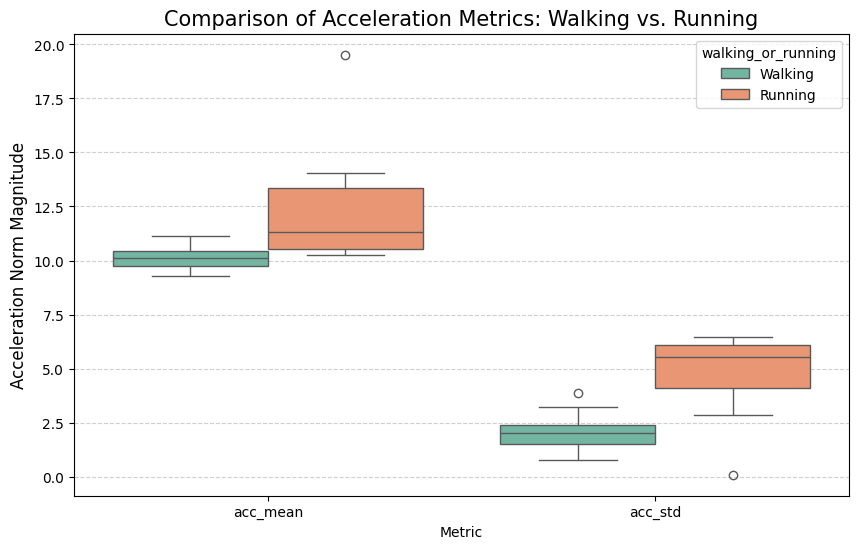

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

features_df = recordings_data['acc_norm_data'].apply(lambda df: pd.Series({
    'acc_mean': df['acc_norm'].mean(),
    'acc_std':  df['acc_norm'].std()
}))

for col in features_df.columns:
    if col not in recordings_data.columns:
        recordings_data[col] = features_df[col]

plot_df = recordings_data.melt(
    id_vars='walking_or_running',
    value_vars=['acc_mean', 'acc_std'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x='Metric', y='Value', hue='walking_or_running', palette='Set2')

plt.title('Comparison of Acceleration Metrics: Walking vs. Running', fontsize=15)
plt.ylabel('Acceleration Norm Magnitude', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Step Calculation - Good Recordings

In [15]:
from scipy.signal import butter, filtfilt, find_peaks
from numpy.fft import rfft, rfftfreq
import numpy as np
import pandas as pd

In [16]:
def butter_bandpass_safe(data, lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    if nyq <= lowcut:
        return data - np.mean(data)
    safe_highcut = min(highcut, nyq * 0.9)

    low = lowcut / nyq
    high = safe_highcut / nyq

    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def extract_step_features(row):
    sensor_data = row['sensor_data']
    norm_df = row['acc_norm_data'].sort_values('Time [sec]')

    signal_raw = norm_df['acc_norm'].values
    time = norm_df['Time [sec]'].values
    duration_total = time[-1] - time[0]
    fs = len(time) / duration_total if duration_total > 0.01 else 50

    # Signal Processing (Bandpass)
    signal = (signal_raw - np.mean(signal_raw)) / (np.std(signal_raw) + 1e-6)
    try:
        clean_signal = butter_bandpass_safe(signal, 0.7, 4.0, fs)
    except:
        clean_signal = signal - np.mean(signal)

    # Time Domain Features (Peak Counting)
    peaks, _ = find_peaks(clean_signal, prominence=0.6, distance=max(1, int(fs/4)))

    if len(peaks) > 1:
        active_duration = time[peaks[-1]] - time[peaks[0]]
    else:
        active_duration = 0

    # Frequency Domain Features (FFT)
    detrended = clean_signal - np.mean(clean_signal)
    N = len(clean_signal)
    yf = np.abs(rfft(detrended))
    xf = rfftfreq(N, 1/fs)

    idx_valid = (xf >= 0.5) & (xf <= 4.5)

    if any(idx_valid):
        valid_yf = yf[idx_valid]
        valid_xf = xf[idx_valid]
        peak_idx = np.argmax(valid_yf)

        dominant_freq = valid_xf[peak_idx]
        rhythm_strength = valid_yf[peak_idx]
    else:
        dominant_freq = 0
        rhythm_strength = 0

    # Calculate "FFT Estimated Steps" (Freq * Time)
    fft_estimated_steps = dominant_freq * active_duration

    # Gyro Features
    gyro_cols = ['GYRO X', 'GYRO Y', 'GYRO Z']
    gyro_data = sensor_data[gyro_cols].values
    gyro_norm = np.linalg.norm(gyro_data, axis=1)

    return pd.Series({
        'raw_peak_count': len(peaks),
        'fft_estimated_steps': fft_estimated_steps,
        'dominant_freq': dominant_freq,
        'active_duration': active_duration,
        'rhythm_strength': rhythm_strength,
        'sig_std': np.std(signal_raw),
        'gyro_mean': np.mean(gyro_norm),
        'gyro_std': np.std(gyro_norm),
        'is_running': 1 if row['walking_or_running'] == 'Running' else 0
    })

features = recordings_data.apply(extract_step_features, axis=1)




In [17]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def train_split_models(features, actual_steps):
    y_pred_final = np.zeros(len(actual_steps))
    all_mae_scores = []

    # train separately for walking and running
    for activity in [0, 1]:
        mask = (features['is_running'] == activity)
        if mask.sum() < 5: continue

        X_sub = features[mask]
        y_sub = actual_steps[mask]

        model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
        kf = KFold(n_splits=5, shuffle=True, random_state=42)

        preds = cross_val_predict(model, X_sub, y_sub, cv=kf)
        y_pred_final[mask.values] = preds

        fold_maes = -cross_val_score(model, X_sub, y_sub, cv=kf, scoring='neg_mean_absolute_error')
        all_mae_scores.extend(fold_maes)

    return y_pred_final, np.array(all_mae_scores)

y_pred_final, mae_scores = train_split_models(features, recordings_data['actual_step_count'])

# Evaluation
overall_mae = mean_absolute_error(recordings_data['actual_step_count'], y_pred_final)
mae_std = mae_scores.std()
r2 = r2_score(recordings_data['actual_step_count'], y_pred_final)

print(f"MAE: {overall_mae:.2f} ± {mae_std:.2f} steps")
print(f"R² Score: {r2:.4f}")

final_model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
final_model.fit(features, recordings_data['actual_step_count'])

feature_names = features.columns
importances = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)

print("\n📊 Feature Importance:")
print(importances)



MAE: 13.91 ± 8.24 steps
R² Score: 0.6640

📊 Feature Importance:
raw_peak_count         0.369019
rhythm_strength        0.168203
fft_estimated_steps    0.153333
gyro_std               0.146072
gyro_mean              0.054621
dominant_freq          0.050587
sig_std                0.031613
active_duration        0.020505
is_running             0.006048
dtype: float64


## Step Calculation - Dead gyro recordings

In [18]:
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

In [19]:
features_dead_gyro = dead_gyro_df.apply(extract_step_features, axis=1)

X_dead = features_dead_gyro[['raw_peak_count', 'active_duration', 'sig_std']].copy()
X_dead['active_duration'] = X_dead['active_duration'].abs()
y_dead = dead_gyro_df['actual_step_count']

simple_model = HuberRegressor()
n_folds = max(2, min(5, len(X_dead)))
kf_simple = KFold(n_splits=n_folds, shuffle=True, random_state=42)

cv_results = cross_validate(simple_model, X_dead, y_dead,
                            cv=kf_simple,
                            scoring='neg_mean_absolute_error',
                            return_train_score=False)

mae_scores = -cv_results['test_score']

print(f"Mean MAE: {mae_scores.mean():.4f} ± {mae_scores.std():.4f} steps")

Mean MAE: 0.2501 ± 0.5000 steps


## Prediction for test data
uncomment and add a zip file named 'test_data' to get a prediction

In [ ]:
# import zipfile
# import os
# import pandas as pd
# import numpy as np
# from scipy.signal import find_peaks


# TEST_ZIP_PATH = 'test_data.zip'
# EXTRACT_PATH = 'test_extracted/'

# def load_test_file(filepath):
#     try:
#         with open(filepath, 'r') as f:
#             lines = f.readlines()

#         data = pd.read_csv(filepath, skiprows=4)
#         required_cols = ['Time [sec]', 'ACC X', 'ACC Y', 'ACC Z', 'GYRO X', 'GYRO Y', 'GYRO Z']
#         if not all(col in data.columns for col in required_cols):
#             return None

#         return data
#     except Exception as e:
#         print(f"Error loading {filepath}: {e}")
#         return None

# def process_recording(file_name, data):
#     acc_cols = ['ACC X', 'ACC Y', 'ACC Z']
#     data['acc_norm'] = np.linalg.norm(data[acc_cols].values, axis=1)

#     gyro_cols = ['GYRO X', 'GYRO Y', 'GYRO Z']
#     data['gyro_norm'] = np.linalg.norm(data[gyro_cols].values, axis=1)

#     gyro_std = data['gyro_norm'].std()
#     gyro_mean = data['gyro_norm'].mean()

#     # DETERMINE IF GYRO IS DEAD
#     is_gyro_dead = gyro_std < 0.05
#     time = data['Time [sec]'].values
#     duration = time[-1] - time[0] if len(time) > 1 else 1

#     peaks, _ = find_peaks(data['acc_norm'], prominence=1.0, distance=20)
#     estimated_steps = len(peaks)
#     estimated_cadence = (estimated_steps / (duration / 60)) if duration > 0 else 0

#     clf_features = {
#         'acc_mean': data['acc_norm'].mean(),
#         'acc_std': data['acc_norm'].std(),
#         'acc_max': data['acc_norm'].max(),
#         'actual_cadence': estimated_cadence
#     }

#     mock_row = pd.Series({
#         'sensor_data': data,
#         'acc_norm_data': data[['Time [sec]', 'acc_norm']],
#         'walking_or_running': 'Unknown'
#     })

#     step_features = extract_step_features(mock_row)

#     return {
#         'file_name': file_name,
#         'is_gyro_dead': is_gyro_dead,
#         **clf_features,
#         **step_features
#     }

# with zipfile.ZipFile(TEST_ZIP_PATH, 'r') as zip_ref:
#     zip_ref.extractall(EXTRACT_PATH)
#     extracted_files = zip_ref.namelist()

# results = []


# for file in extracted_files:
#     if not file.endswith('.csv') or file.startswith('__MACOSX'):
#         continue

#     file_path = os.path.join(EXTRACT_PATH, file)
#     data = load_test_file(file_path)

#     if data is not None and not data.empty:
#         features_dict = process_recording(file, data)
#         results.append(features_dict)

# test_df = pd.DataFrame(results)

# if test_df.empty:
#     print("No valid CSV files found in the zip.")
# else:
#     print("Feature Extraction Complete. Running Models...")


#     # PREDICT ACTIVITY
#     X_clf_test = test_df[['acc_mean', 'acc_std', 'acc_max', 'actual_cadence']]
#     test_df['Predicted_Activity'] = final_classifier.predict(X_clf_test)

#     # PREDICT STEPS
#     final_predictions = []

#     for idx, row in test_df.iterrows():
#         if row['is_gyro_dead']:
#             X_input = pd.DataFrame([row[['raw_peak_count', 'active_duration', 'sig_std']]])
#             X_input['active_duration'] = X_input['active_duration'].abs()

#             pred = final_step_model_dead.predict(X_input)[0]
#             model_used = "Huber (Dead Gyro)"

#         else:
#             X_input = pd.DataFrame([row[['raw_peak_count', 'rhythm_strength', 'fft_estimated_steps', 'gyro_std']]])

#             pred = final_step_model_good.predict(X_input)[0]
#             model_used = "GradBoost (Good Gyro)"

#         final_predictions.append((int(pred), model_used))

#     test_df['Predicted_Steps'] = [p[0] for p in final_predictions]
#     test_df['Model_Used'] = [p[1] for p in final_predictions]

#     output_cols = ['file_name', 'Predicted_Activity', 'Predicted_Steps', 'Model_Used', 'is_gyro_dead']
#     display_df = test_df[output_cols].sort_values('file_name')

#     print("\nFINAL RESULTS:")
#     print(display_df.head(10))

#     display_df.to_csv('test_predictions.csv', index=False)
#     print("\n Saved full results to 'test_predictions.csv'")